In [37]:
# Install Numba
# !pip install numpy numba


# Packages
import numba
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib  # Importerer biblioteket importlib, som giver mulighed for at genindlæse moduler
from statsmodels.tsa.ar_model import AutoReg # Importerer AutoReg-klassen fra statsmodels.tsa.ar_model, som bruges til autoregressive modeller
import sys                              # provides access to Pythons search path
import os                               # Gives Python access to file system functions, such as getting the current working directory
sys.path.append(os.path.abspath(".."))  # Tells python to also seach for modules in the parent directory (where the "functions" folder is located)


# Import self-defined functions
from functions import master_function

# Genindlæser master_function.py fra disk og opdaterer modulet i hukommelsen
importlib.reload(master_function)  # Genindlæser master_function.py fra disk og opdaterer modulet i hukommelsen

<module 'functions.master_function' from '/Users/tobiasfriumjordhoi/Documents/KU/Bachelor/6. semester/Bachelor/local_repo/functions/master_function.py'>

### Data

Vi importerer følgende data serier:
1. log_sp500.csv

In [38]:
# 1. Load CSV file log_sp500
csv_file_log_sp500 = pd.read_csv("../data/log_sp500.csv") 
log_sp500 = np.asarray(csv_file_log_sp500["Close"])  # Converts the column "log_sp500" in the csv-file to a numpy-array

### Testing
Tests af ADF, SADF og GSADF

In [ ]:
res = master_function.radf(
    log_sp500, 
    r0=0.05, 
    lags=0, 
    trend="c")

print(res)

cv = master_function.radf_cv(log_sp500, r0=0.05, lags=0, trend="c", nrep=1999, seed=123)

print(cv)

{'adf': -0.2404935138116976, 'sadf': 1.5137252421677148, 'gsadf': 2.813481950922226, 'minw': 21}
{'90': {'adf': np.float64(-0.4140885326573559), 'sadf': np.float64(1.2330830675310658), 'gsadf': np.float64(2.317054130556416)}, '95': {'adf': np.float64(-0.02992972317231361), 'sadf': np.float64(1.5470856333905822), 'gsadf': np.float64(2.5660082827698503)}, '99': {'adf': np.float64(0.733555589699447), 'sadf': np.float64(2.077984930163837), 'gsadf': np.float64(3.180650645886973)}}


Test af BSADF

In [39]:
#BSADF
res = master_function.radf_bsadf(log_sp500, r0=0.05, lags=0, trend="c")

bsadf = res["bsadf"]

print(bsadf[:21]) # Print the first 21 values of the bsadf statistic

#BSADF CV
cv = master_function.radf_bsadf_cv(len(log_sp500), r0=0.01, nrep=5000, seed=123)

cv95 = cv["95"]

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan -1.00720095]


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Vi kan nu plotte BSADF mod de kritiske værdier

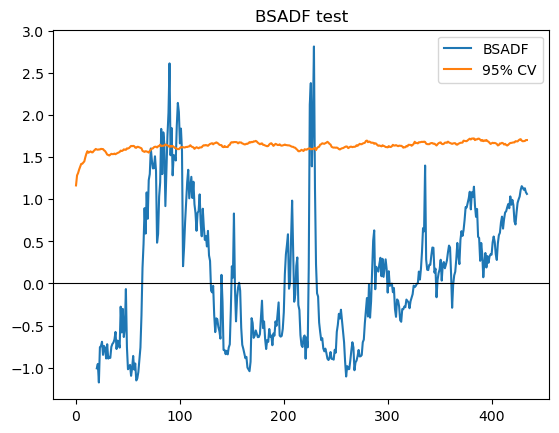

In [40]:
plt.plot(bsadf, label="BSADF")
plt.plot(cv95, label="95% CV") #, linestyle="--"
plt.axhline(0, color="black", linewidth=0.8)

plt.legend()
plt.title("BSADF test")
plt.show()